# Concorde TSP Solver — Implémentation Python

Reproduction du pipeline Concorde : **LP relaxation + DFJ lazy constraints + branch-and-cut** via OR-Tools SCIP.

> Concorde est le solveur TSP exact de référence (Applegate, Bixby, Chvátal, Cook).
> Il a résolu des instances jusqu'à **85 900 villes** grâce aux coupes comb et blossom.
> Cette implémentation reproduit son cœur : DFJ lazy + moteur MIP SCIP.

In [1]:
import math
import random
import time
import tracemalloc
import matplotlib.pyplot as plt
from ortools.linear_solver import pywraplp
from ortools.sat.python import cp_model  # pour comparaison avec MTZ

## 1. Génération de graphe

In [2]:
def generate_graph(n: int, seed: int | None = None) -> list[tuple[float, float]]:
    rng = random.Random(seed)
    return [(rng.uniform(0, 100), rng.uniform(0, 100)) for _ in range(n)]

## 2. Solveur Concorde-inspired (LP + DFJ lazy + SCIP)

In [3]:
def find_subtours(n: int, x_val: list[list[float]]) -> list[list[int]]:
    """Détecte les sous-tours dans une solution (entière ou fractionnaire arrondie)."""
    visited, subtours = [False] * n, []
    for start in range(n):
        if visited[start]:
            continue
        tour, cur = [], start
        while not visited[cur]:
            visited[cur] = True
            tour.append(cur)
            nxt = next((j for j in range(n) if j != cur and x_val[cur][j] > 0.5), None)
            if nxt is None:
                break
            cur = nxt
        subtours.append(tour)
    return subtours


def solve_tsp_concorde(
    cities: list[tuple[float, float]],
    time_limit: float = 120.0,
) -> tuple[list[int], float, int, int]:
    """
    Concorde-inspired : LP relaxation + DFJ lazy constraints + branch-and-cut SCIP.

    Différences clés vs MTZ :
    - Moteur MIP SCIP (branch-and-cut LP natif) au lieu de CP-SAT
    - Pas de variables u_i : anti sous-tours via coupes DFJ lazy seulement
    - Relaxation LP de qualité bien supérieure à MTZ

    Retourne : (tour, distance, nb_iterations, nb_coupes_djf)
    """
    n = len(cities)

    def dist(i: int, j: int) -> float:
        dx = cities[i][0] - cities[j][0]
        dy = cities[i][1] - cities[j][1]
        return math.hypot(dx, dy)

    forbidden: list[frozenset] = []
    iteration = 0

    while True:
        iteration += 1
        solver = pywraplp.Solver.CreateSolver("SCIP")
        solver.SetTimeLimit(int(time_limit * 1000))

        x = [[solver.IntVar(0, 1, f"x_{i}_{j}") for j in range(n)]
             for i in range(n)]

        # Contraintes de degré
        for i in range(n):
            solver.Add(x[i][i] == 0)
            solver.Add(sum(x[i][j] for j in range(n) if j != i) == 1)
            solver.Add(sum(x[j][i] for j in range(n) if j != i) == 1)

        # Coupes DFJ accumulées
        for S in forbidden:
            S_list = list(S)
            solver.Add(
                sum(x[i][j] for i in S_list for j in S_list if i != j)
                <= len(S_list) - 1
            )

        # Objectif
        solver.Minimize(
            sum(dist(i, j) * x[i][j]
                for i in range(n) for j in range(n) if i != j)
        )

        status = solver.Solve()
        if status not in (pywraplp.Solver.OPTIMAL, pywraplp.Solver.FEASIBLE):
            return [], float("inf"), iteration, len(forbidden)

        x_val = [[x[i][j].solution_value() for j in range(n)] for i in range(n)]
        subtours = find_subtours(n, x_val)

        print(f"  Itération {iteration:>2} — {len(subtours)} cycle(s)", end="")

        if len(subtours) == 1:
            print(" → tour unique ✓")
            break

        new_cuts = 0
        for st in subtours:
            fs = frozenset(st)
            if fs not in forbidden and len(fs) < n:
                forbidden.append(fs)
                new_cuts += 1
        print(f"  — {new_cuts} coupe(s) DFJ ajoutée(s) (total : {len(forbidden)})")

    tour = subtours[0]
    total = (
        sum(dist(tour[k], tour[k + 1]) for k in range(n - 1))
        + dist(tour[-1], tour[0])
    )
    return tour, total, iteration, len(forbidden)

## 3. Visualisation

In [4]:
def plot_tour(cities, tour, distance, title):
    fig, ax = plt.subplots(figsize=(8, 8))
    tour_closed = tour + [tour[0]]
    for k in range(len(tour_closed) - 1):
        i, j = tour_closed[k], tour_closed[k + 1]
        ax.plot([cities[i][0], cities[j][0]], [cities[i][1], cities[j][1]],
                "b-", linewidth=1.2, alpha=0.7)
    xs, ys = [c[0] for c in cities], [c[1] for c in cities]
    ax.scatter(xs, ys, c="red", s=60, zorder=5)
    for idx, (cx, cy) in enumerate(cities):
        ax.annotate(str(idx), (cx, cy), textcoords="offset points",
                    xytext=(5, 5), fontsize=8)
    ax.scatter([cities[tour[0]][0]], [cities[tour[0]][1]],
               c="green", s=120, zorder=6, label="Départ")
    ax.set_title(f"{title}\nDistance : {distance:.2f}")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 4. Paramètres

In [5]:
N_CITIES_LIST = [1, 10, 100, 1_000, 10_000, 1_000_000]
SEED          = 42
TIME_LIMIT    = 60.0

## 5. Exécution — résultats par taille


  n = 1 villes
  Distance  : —
  Itérations: 1 | Coupes DFJ : 0
  Temps     : 0.06s

  n = 10 villes
  Itération  1 — 5 cycle(s)  — 5 coupe(s) DFJ ajoutée(s) (total : 5)
  Itération  2 — 1 cycle(s) → tour unique ✓
  Distance  : 264.139
  Itérations: 2 | Coupes DFJ : 5
  Temps     : 0.03s


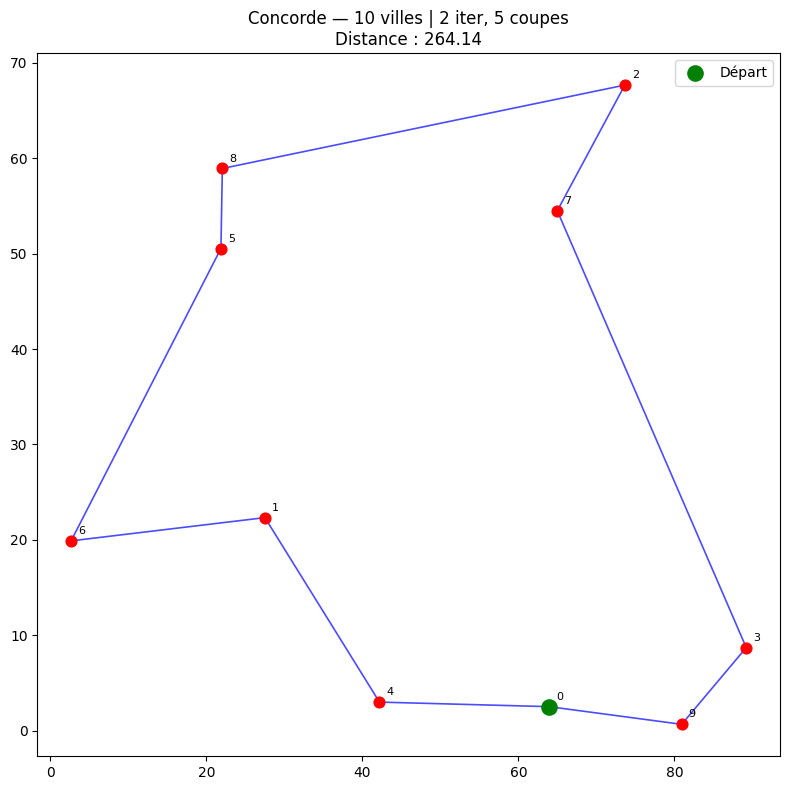


  n = 100 villes
  Itération  1 — 47 cycle(s)  — 47 coupe(s) DFJ ajoutée(s) (total : 47)
  Itération  2 — 16 cycle(s)  — 16 coupe(s) DFJ ajoutée(s) (total : 63)
  Itération  3 — 9 cycle(s)  — 9 coupe(s) DFJ ajoutée(s) (total : 72)
  Itération  4 — 9 cycle(s)  — 9 coupe(s) DFJ ajoutée(s) (total : 81)
  Itération  5 — 3 cycle(s)  — 3 coupe(s) DFJ ajoutée(s) (total : 84)
  Itération  6 — 1 cycle(s) → tour unique ✓
  Distance  : 792.101
  Itérations: 6 | Coupes DFJ : 84
  Temps     : 7.10s


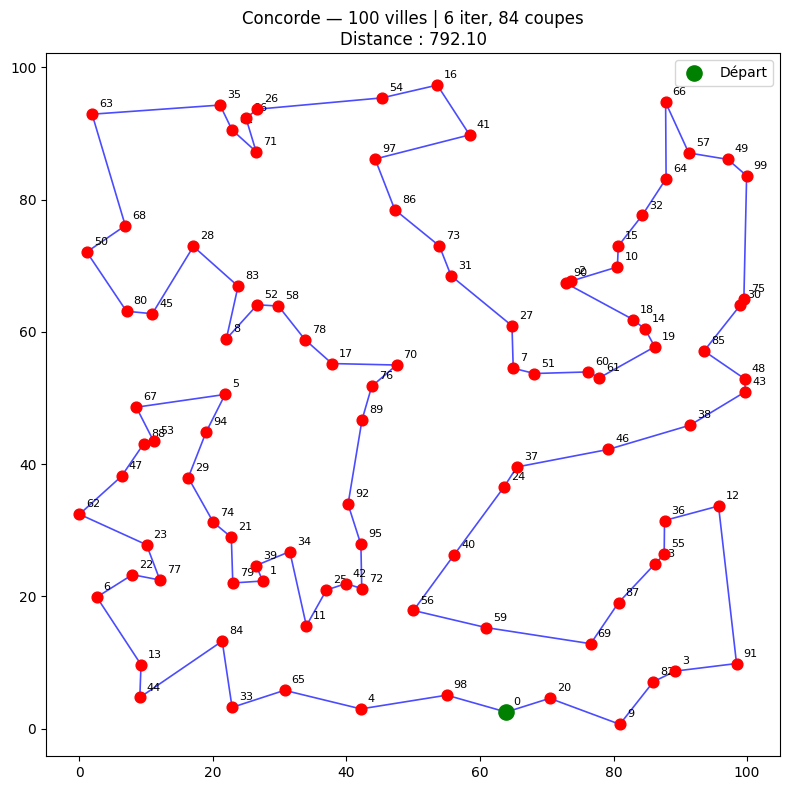


  n = 1,000 villes
  Itération  1 — 455 cycle(s)  — 455 coupe(s) DFJ ajoutée(s) (total : 455)
  Itération  2 — 8 cycle(s)  — 8 coupe(s) DFJ ajoutée(s) (total : 463)
  Itération  3 — 14 cycle(s)  — 14 coupe(s) DFJ ajoutée(s) (total : 477)
  Itération  4 — 11 cycle(s)  — 11 coupe(s) DFJ ajoutée(s) (total : 488)
  Itération  5 — 6 cycle(s)  — 6 coupe(s) DFJ ajoutée(s) (total : 494)
  Itération  6 — 2 cycle(s)  — 2 coupe(s) DFJ ajoutée(s) (total : 496)
  Itération  7 — 2 cycle(s)  — 2 coupe(s) DFJ ajoutée(s) (total : 498)
  Itération  8 — 1 cycle(s) → tour unique ✓
  Distance  : 3000.251
  Itérations: 8 | Coupes DFJ : 498
  Temps     : 781.54s


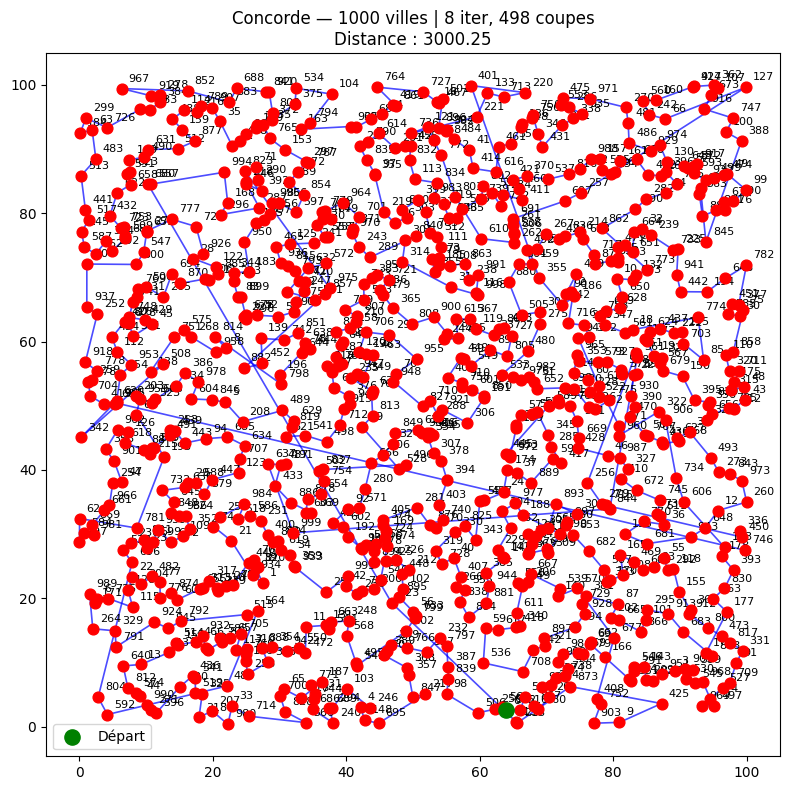


  n = 10,000 villes


In [ ]:
for N_CITIES in N_CITIES_LIST:
    print(f"\n{'='*55}")
    print(f"  n = {N_CITIES:,} villes")
    print(f"{'='*55}")

    cities = generate_graph(N_CITIES, seed=SEED)

    t0 = time.perf_counter()
    tour, distance, iters, cuts = solve_tsp_concorde(cities, time_limit=TIME_LIMIT)
    elapsed = time.perf_counter() - t0

    print(f"  Distance  : {distance:.3f}" if distance != float("inf") else "  Distance  : —")
    print(f"  Itérations: {iters} | Coupes DFJ : {cuts}")
    print(f"  Temps     : {elapsed:.2f}s")

    if tour:
        plot_tour(cities, tour, distance,
                  f"Concorde — {N_CITIES} villes | {iters} iter, {cuts} coupes")

## 6. Benchmark — performances selon le nombre de villes

In [ ]:
BENCHMARK_SIZES = [1, 10, 100, 1_000, 10_000, 100_000]
results = []

for n in BENCHMARK_SIZES:
    print(f"[n={n:>7}] ", end="", flush=True)
    cities = generate_graph(n, seed=SEED)
    tracemalloc.start()
    t0 = time.perf_counter()
    try:
        tour, distance, iters, cuts = solve_tsp_concorde(cities, time_limit=TIME_LIMIT)
    except Exception as e:
        elapsed = time.perf_counter() - t0
        tracemalloc.stop()
        print(f"ERREUR — {e}")
        results.append({"n": n, "statut": "ERREUR", "distance": None,
                        "temps": elapsed, "memoire": None, "iters": None, "cuts": None})
        continue
    elapsed = time.perf_counter() - t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    status = "OPTIMAL" if distance != float("inf") else "UNKNOWN"
    dist_val = distance if distance != float("inf") else None
    print(f"{status:<10}  dist={dist_val}  iter={iters}  coupes={cuts}  t={elapsed:.2f}s  mém={peak/1e6:.1f}MB")
    results.append({"n": n, "statut": status, "distance": dist_val,
                    "temps": elapsed, "memoire": peak/1e6, "iters": iters, "cuts": cuts})

In [ ]:
labels  = [str(r["n"]) for r in results]
temps   = [r["temps"]   if r["temps"]   is not None else 0 for r in results]
memoire = [r["memoire"] if r["memoire"] is not None else 0 for r in results]
dists   = [r["distance"] if r["distance"] is not None else 0 for r in results]
iters_l = [r["iters"] if r["iters"] is not None else 0 for r in results]
statuts = [r["statut"] for r in results]

COLOR_MAP = {"OPTIMAL": "#2ecc71", "UNKNOWN": "#95a5a6", "ERREUR": "#e74c3c"}
colors = [COLOR_MAP.get(s, "#bdc3c7") for s in statuts]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Benchmark Concorde-inspired (OR-Tools SCIP + DFJ lazy)", fontsize=13, fontweight="bold")

# Temps
ax = axes[0]
bars = ax.bar(labels, temps, color=colors, edgecolor="white")
ax.set_title("Temps de résolution (s)")
ax.set_xlabel("Nombre de villes")
ax.set_yscale("symlog", linthresh=0.01)
for bar, r in zip(bars, results):
    lbl = f"{r['temps']:.2f}s" if r["temps"] is not None else "N/A"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            lbl, ha="center", va="bottom", fontsize=7)

# Mémoire
ax = axes[1]
bars = ax.bar(labels, memoire, color=colors, edgecolor="white")
ax.set_title("Mémoire (MB)")
ax.set_xlabel("Nombre de villes")
for bar, r in zip(bars, results):
    lbl = f"{r['memoire']:.1f}" if r["memoire"] is not None else "N/A"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            lbl, ha="center", va="bottom", fontsize=7)

# Distance
ax = axes[2]
bars = ax.bar(labels, dists, color=colors, edgecolor="white")
ax.set_title("Distance du tour")
ax.set_xlabel("Nombre de villes")
for bar, r in zip(bars, results):
    lbl = f"{r['distance']:.1f}" if r["distance"] is not None else "N/A"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            lbl, ha="center", va="bottom", fontsize=7)

# Coupes DFJ
ax = axes[3]
bars = ax.bar(labels, iters_l, color=colors, edgecolor="white")
ax.set_title("Itérations (coupes DFJ)")
ax.set_xlabel("Nombre de villes")
for bar, r in zip(bars, results):
    lbl = str(r["iters"]) if r["iters"] is not None else "N/A"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            lbl, ha="center", va="bottom", fontsize=7)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in COLOR_MAP.items() if s in statuts]
fig.legend(handles=legend_elements, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.05), frameon=False)
plt.tight_layout()
plt.show()